## Part 01

In [2]:

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


df = pd.read_csv(r"C:\Users\User\PyCharmMiscProject\Datasets\Superstore_Data.csv")
df

,Order Date,Sales,Profit
0,17-10-2013,5175.1710,919.9710
1,07-11-2011,1822.0800,564.8400
2,14-04-2012,5244.8400,996.4800
3,06-06-2013,3701.5200,1036.0800
4,25-02-2012,1878.7200,582.3600
...,...,...,...
5694,14-01-2013,38.9709,-32.3991
5695,12-11-2014,6.9000,-0.8400
5696,03-11-2011,17.2800,-13.9200
5697,26-07-2013,30.6180,1.0080


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5699 entries, 0 to 5698
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Order Date  5699 non-null   object 
 1   Sales       5699 non-null   float64
 2   Profit      5699 non-null   float64
dtypes: float64(2), object(1)
memory usage: 133.7+ KB


In [4]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

In [5]:
df.sort_values(by=["Order Date"], inplace=True)
df.head()

,Order Date,Sales,Profit
5073,2011-01-01,55.242,15.342
3056,2011-01-01,120.366,36.036
4083,2011-01-01,113.670,37.770
424,2011-01-03,912.456,-319.464
5517,2011-01-03,6.006,0.546


In [6]:
df.tail()#so the data is 4 years

,Order Date,Sales,Profit
4875,2014-12-30,8.5407,2.3607
1455,2014-12-30,255.2850,-47.6550
4345,2014-12-30,10.8540,-6.6960
1804,2014-12-31,300.2400,84.0600
3956,2014-12-31,39.6000,6.6600


In [7]:
df.reset_index(drop=True, inplace=True)
df

,Order Date,Sales,Profit
0,2011-01-01,55.2420,15.3420
1,2011-01-01,120.3660,36.0360
2,2011-01-01,113.6700,37.7700
3,2011-01-03,912.4560,-319.4640
4,2011-01-03,6.0060,0.5460
...,...,...,...
5694,2014-12-30,8.5407,2.3607
5695,2014-12-30,255.2850,-47.6550
5696,2014-12-30,10.8540,-6.6960
5697,2014-12-31,300.2400,84.0600


In [8]:
df.set_index("Order Date", inplace=True)#Explicit index when we add new index and implicit is when index is already exist index
df

,Sales,Profit
Order Date,,
2011-01-01,55.2420,15.3420
2011-01-01,120.3660,36.0360
2011-01-01,113.6700,37.7700
2011-01-03,912.4560,-319.4640
2011-01-03,6.0060,0.5460
...,...,...
2014-12-30,8.5407,2.3607
2014-12-30,255.2850,-47.6550
2014-12-30,10.8540,-6.6960


In [9]:
df.loc['2011-01-01'] #explicit index

,Sales,Profit
Order Date,,
2011-01-01,55.242,15.342
2011-01-01,120.366,36.036
2011-01-01,113.670,37.770


In [10]:
df.iloc[0:3] #implicit index


,Sales,Profit
Order Date,,
2011-01-01,55.242,15.342
2011-01-01,120.366,36.036
2011-01-01,113.670,37.770


In [11]:
df["2011-01" : "2011-02"].sum()

Sales     28622.5713
Profit     2330.1513
dtype: float64

In [12]:
df["2011" : "2012"].sum()

Sales     704488.6593
Profit     85321.5993
dtype: float64

In [13]:
# the granularity rule => the more agg of forecast are more accurate it be
# always study data in weeks wise -> month wise -> year wise more agg more stable
# to have a big picture of our data

In [14]:
df = df.groupby(pd.Grouper(freq="ME")).sum()


In [15]:
df.drop(columns= "Profit", inplace=True)

In [16]:
df

,Sales
Order Date,
2011-01-31,15711.7125
2011-02-28,12910.8588
2011-03-31,19472.5632
2011-04-30,15440.3046
2011-05-31,24348.9723
2011-06-30,27260.0196
2011-07-31,15842.8317
2011-08-31,22012.2366
2011-09-30,34613.1849


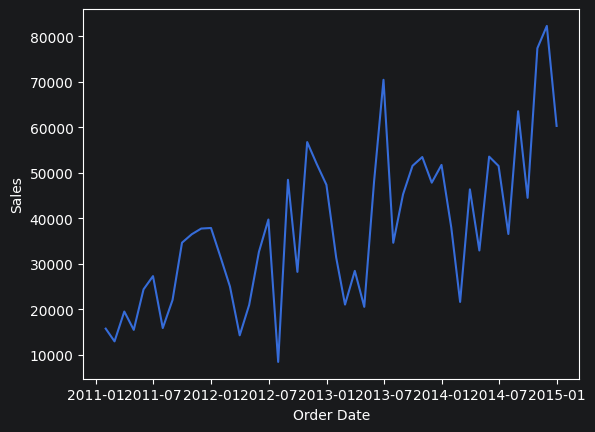

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lineplot(x="Order Date", y="Sales", data=df)
plt.show()

### We have 4 main properties of Time Series Forecasting
- Time Series : Always have some kind of trends (increasing or decreasing)
- Seasonality : Repeating pattern at a constant time interval
- Cyclic nature : A repeating pattern at random time intervals
- Noise : Something Random, you can't explain


every time series data whether stationary TS data or non-stationary TS data

## Part 02 (Stationary Analysis)

In [18]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df["Sales"])
result[1] #second value is the p-value and is not less then 0.5 %

np.float64(0.1987628396941693)

In [19]:
df

,Sales
Order Date,
2011-01-31,15711.7125
2011-02-28,12910.8588
2011-03-31,19472.5632
2011-04-30,15440.3046
2011-05-31,24348.9723
2011-06-30,27260.0196
2011-07-31,15842.8317
2011-08-31,22012.2366
2011-09-30,34613.1849


In [20]:
data_train = df[:42]
data_test = df[42:]

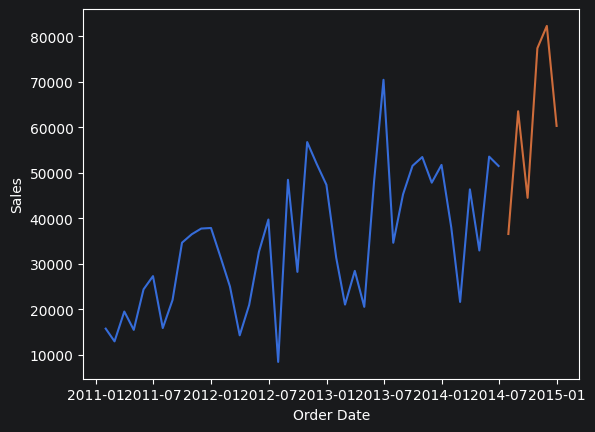

In [23]:
sns.lineplot(x="Order Date", y="Sales", data=data_train)
sns.lineplot(x="Order Date", y="Sales", data=data_test)
plt.show()

### Part 03 Time Series Transformation